In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from iertools.read import read_sql
from dateutil.parser import parse

In [3]:
areas = {"BANO":1.7*2.2, "CIRCULACION":3.7, "COMERCIO":3.4*3+1.2*0.7, "ESCALERA":2.2*2.7, "RECAMARAPA":2.6*4.4+1.7*2.2, "RECAMARAPB":2.6*4.4, "SALA":4.4*3.7}
pesos = {nombre: area / sum(areas.values()) for nombre, area in areas.items()}

In [4]:
f = "../osm/013_modificacion/run/eplusout.sql"
cb = read_sql(f,alias=True)
data_cb = cb.data

In [5]:
temps = data_cb.copy()
temps["Ti_CB"] = sum(temps[f"Ti_{zona}"] * peso for zona, peso in pesos.items())

(np.float64(13149.0), np.float64(13180.0))

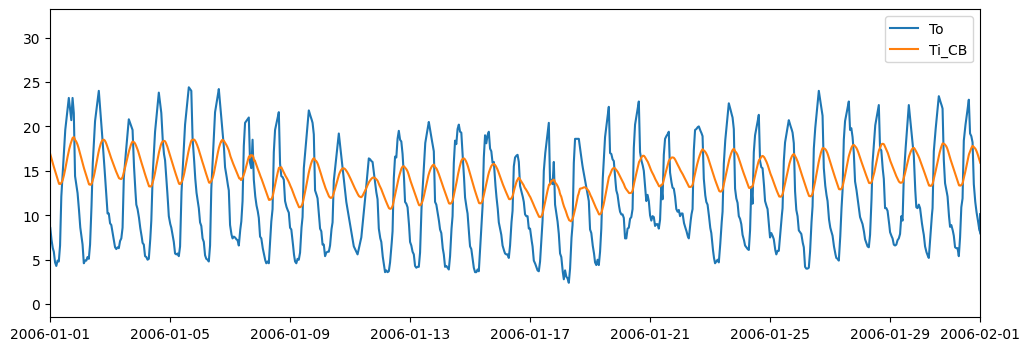

In [6]:
fig, ax = plt.subplots(figsize=(12,4))

f1 = parse("2006-01-01")
f2 = f1 + pd.Timedelta(days=31)

ax.plot(temps.To, label="To")
ax.plot(temps.Ti_CB, label="Ti_CB")

ax.legend()

ax.set_xlim(f1,f2)

In [14]:
# Mean hourly profile for January across all January days
import plotly.graph_objects as go

enero = temps.loc[temps.index.month == 1, ['To', 'Ti_CB']]
mean_january_hour = enero.groupby(enero.index.hour).mean().reindex(range(24))
mean_january_hour.index.name = 'hour'

fig = go.Figure()
fig.add_trace(go.Scatter(x=mean_january_hour.index, y=mean_january_hour['To'], mode='lines+markers', name='To'))
fig.add_trace(go.Scatter(x=mean_january_hour.index, y=mean_january_hour['Ti_CB'], mode='lines+markers', name='Ti_CB'))

fig.update_layout(
    width=900,
    height=450,
    title='January hourly mean profile',
    xaxis_title='Hour of day',
    yaxis_title='Temperature [C]',
    template='plotly_white'
 )
fig

In [7]:
f = "../osm/016_adobe/run/eplusout.sql"
adobe = read_sql(f,alias=True)
data_adobe = adobe.data
temps["Ti_adobe"] = sum(data_adobe[f"Ti_{zona}"] * peso for zona, peso in pesos.items())

(np.float64(13149.0), np.float64(13180.0))

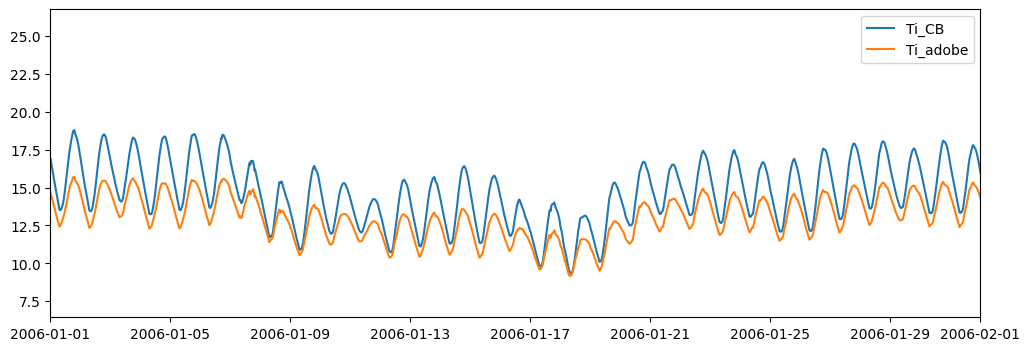

In [8]:
fig, ax = plt.subplots(figsize=(12,4))

f1 = parse("2006-01-01")
f2 = f1 + pd.Timedelta(days=31)

ax.plot(temps.Ti_CB, label="Ti_CB")
ax.plot(temps.Ti_adobe, label="Ti_adobe")

ax.legend()

ax.set_xlim(f1,f2)

#aqui no mejora, pero caundo aumenta ganancia...

In [9]:
f = "../osm/021_ventilacion_diurna/run/eplusout.sql"
ventilacion_diurna = read_sql(f,alias=True)
data_ = ventilacion_diurna.data
temps["Ti_ventilacion_diurna"] = sum(data_[f"Ti_{zona}"] * peso for zona, peso in pesos.items())

(np.float64(13149.0), np.float64(13180.0))

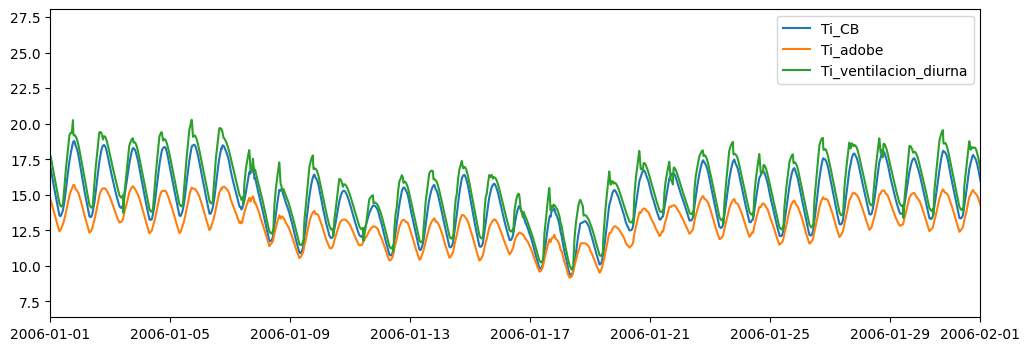

In [10]:
fig, ax = plt.subplots(figsize=(12,4))

f1 = parse("2006-01-01")
f2 = f1 + pd.Timedelta(days=31)

ax.plot(temps.Ti_CB, label="Ti_CB")
ax.plot(temps.Ti_adobe, label="Ti_adobe")
ax.plot(temps.Ti_ventilacion_diurna, label="Ti_ventilacion_diurna")

ax.legend()

ax.set_xlim(f1,f2)

In [11]:
f = "../osm/020_a0p7/run/eplusout.sql"
a0p7 = read_sql(f,alias=True)
data_ = a0p7.data
temps["Ti_a0p7"] = sum(data_[f"Ti_{zona}"] * peso for zona, peso in pesos.items())

(np.float64(13149.0), np.float64(13180.0))

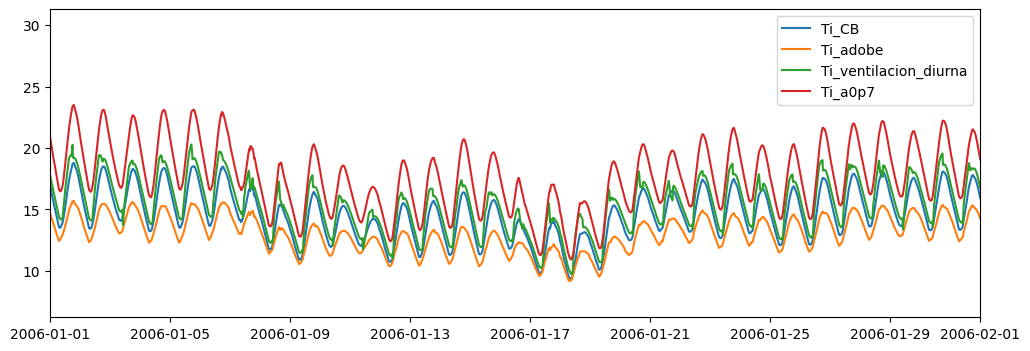

In [12]:
fig, ax = plt.subplots(figsize=(12,4))

f1 = parse("2006-01-01")
f2 = f1 + pd.Timedelta(days=31)

ax.plot(temps.Ti_CB, label="Ti_CB")
ax.plot(temps.Ti_adobe, label="Ti_adobe")
ax.plot(temps.Ti_ventilacion_diurna, label="Ti_ventilacion_diurna")
ax.plot(temps.Ti_a0p7, label="Ti_a0p7")

ax.legend()

ax.set_xlim(f1,f2)

In [21]:
Tma = temps.To["2006-01-01":"2006-01-31"].mean()
Tmin = temps.To["2006-01-01":"2006-01-31"].resample("D").min().mean()
Tmax = temps.To["2006-01-01":"2006-01-31"].resample("D").max().mean()
DeltaTa = Tmax - Tmin
banda = 3.5 / 2
Tn = 13.5 + .54 * Tma
Tn_sup = Tn + banda
Tn_inf = Tn - banda
dt_h = 1 / 6
Tma, Tmin, Tmax, DeltaTa, Tn, Tn_sup, Tn_inf

(np.float64(12.209108223168272),
 np.float64(5.164516129032258),
 np.float64(21.38064516129032),
 np.float64(16.216129032258063),
 np.float64(20.092918440510868),
 np.float64(21.842918440510868),
 np.float64(18.342918440510868))